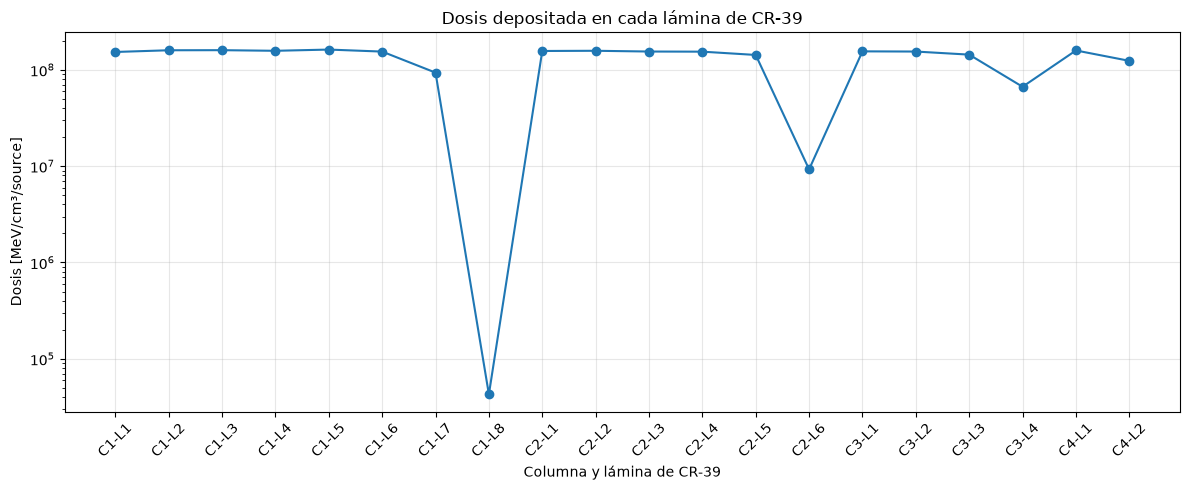

In [2]:
import matplotlib.pyplot as plt

archivo = "../out/dosis_CR39_por_bloque.out"

regiones = []
dosis = []

leyendo = False

with open(archivo, "r") as f:
    for linea in f:

        if "#  num    reg" in linea:
            leyendo = True
            continue

        if leyendo and "#   sum over" in linea:
            break

        if leyendo:
            datos = linea.split()

            if len(datos) >= 5:
                try:
                    region = int(datos[1])
                    valor_dosis = float(datos[3])

                    regiones.append(region)
                    dosis.append(valor_dosis)

                except ValueError:
                    pass


etiquetas = []

for region in regiones:

    if 7011 <= region <= 7018:
        columna = 1
        lamina = region - 7010

    elif 7021 <= region <= 7026:
        columna = 2
        lamina = region - 7020

    elif 7031 <= region <= 7034:
        columna = 3
        lamina = region - 7030

    elif 7041 <= region <= 7042:
        columna = 4
        lamina = region - 7040

    etiquetas.append(f"C{columna}-L{lamina}")


plt.figure(figsize=(12, 5))

plt.plot(etiquetas, dosis, "o-")

plt.xlabel("Columna y lámina de CR-39")
plt.ylabel("Dosis [MeV/cm³/source]")
plt.title("Dosis depositada en cada lámina de CR-39")

plt.yscale("log")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

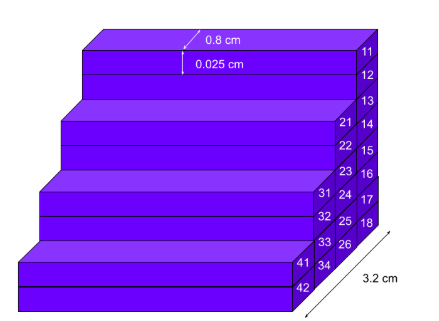

In [3]:
columnas = {
    1: dosis[0:8],
    2: dosis[8:14],
    3: dosis[14:18],
    4: dosis[18:20]
}

for columna, valores in columnas.items():

    print(f"\nColumna {columna}")

    for i in range(len(valores) - 1):

        caida = (valores[i] - valores[i+1]) / valores[i] * 100

        print(
            f"L{i+1} → L{i+2}: {caida:.2f} %"
        )


Columna 1
L1 → L2: -4.16 %
L2 → L3: -0.22 %
L3 → L4: 1.48 %
L4 → L5: -2.97 %
L5 → L6: 4.70 %
L6 → L7: 39.51 %
L7 → L8: 99.95 %

Columna 2
L1 → L2: -0.49 %
L2 → L3: 1.77 %
L3 → L4: 0.32 %
L4 → L5: 7.56 %
L5 → L6: 93.50 %

Columna 3
L1 → L2: 0.46 %
L2 → L3: 7.10 %
L3 → L4: 53.59 %

Columna 4
L1 → L2: 21.95 %


Los resultados muestran que, en las primeras láminas de cada columna, la dosis depositada se mantiene aproximadamente constante, con variaciones pequeñas, lo que indica que los protones todavía atraviesan esas regiones con energía suficiente. Sin embargo, hacia las últimas láminas de cada columna aparece una caída marcada de la dosis, siendo especialmente abrupta en C1-L8 y C2-L6, donde la disminución respecto de la lámina anterior supera ampliamente el 90 %. En la columna 3 también se observa una reducción importante en la última lámina, aunque menos extrema, mientras que en la columna 4 la disminución entre ambas láminas es más moderada. En conjunto, este comportamiento evidencia que el alcance de los protones depende del espesor total de CR-39 atravesado y permite identificar en qué lámina de cada columna comienza a agotarse significativamente el haz.